# Creating an Autoencoder to compress and decompress Fashion MNIST

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.datasets import fashion_mnist
import numpy as np
import matplotlib.pyplot as plt

In [11]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()
x_train.shape

(60000, 28, 28)

In [12]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [25]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
model = Sequential([
    Input(shape=(28, 28, 1)),

    # Encoder
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2), padding='same'),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2), padding='same'),

    # Decoder
    UpSampling2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    UpSampling2D((2, 2)),
    Conv2D(1, (3, 3), activation='sigmoid', padding='same'),
])

In [26]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,569 (146.75 KB)

 Trainable params: 37,569 (146.75 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(optimizer='adam', loss='mse', metrics=['mse'])
history = model.fit(x_train, x_train, epochs=10, batch_size=128,
                    validation_data=(x_test, x_test))

Epoch 1/10


I0000 00:00:1744138317.673422    8146 service.cc:152] XLA service 0x7f07a8009e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744138317.673477    8146 service.cc:160]   StreamExecutor device (0): NVIDIA T500, Compute Capability 7.5
I0000 00:00:1744138317.898706    8146 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/469 ━━━━━━━━━━━━━━━━━━━━ 35s 77ms/step - loss: 0.1679 - mse: 0.1679

I0000 00:00:1744138323.748734    8146 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 48ms/step - loss: 0.0350 - mse: 0.0350 - val_loss: 0.0097 - val_mse: 0.0097
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0089 - mse: 0.0089 - val_loss: 0.0068 - val_mse: 0.0068
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - loss: 0.0062 - mse: 0.0062 - val_loss: 0.0054 - val_mse: 0.0054
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.0051 - mse: 0.0051 - val_loss: 0.0048 - val_mse: 0.0048
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 0.0046 - mse: 0.0046 - val_loss: 0.0042 - val_mse: 0.0042
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - loss: 0.0042 - mse: 0.0042 - val_loss: 0.0040 - val_mse: 0.0040
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 43s 90ms/step - loss: 0.0039 - mse: 0.0039 - val_loss: 0.0037 - val_mse: 0.0037
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - loss: 0.0037 - mse: 0.0037 - val_loss: 0.0036 - val_mse: 0.0036
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/st

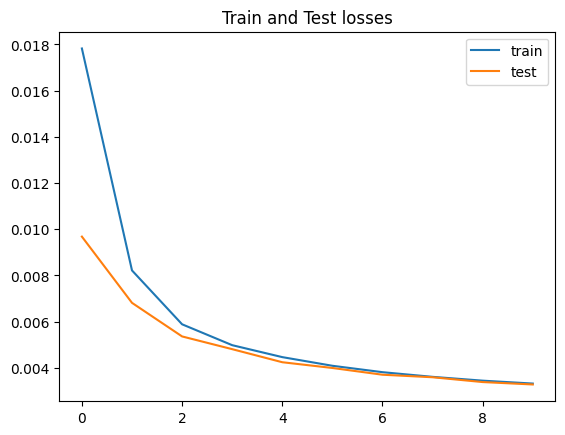

In [30]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title("Train and Test losses")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


Text(0.5, 0.98, 'Autoencoder Results')

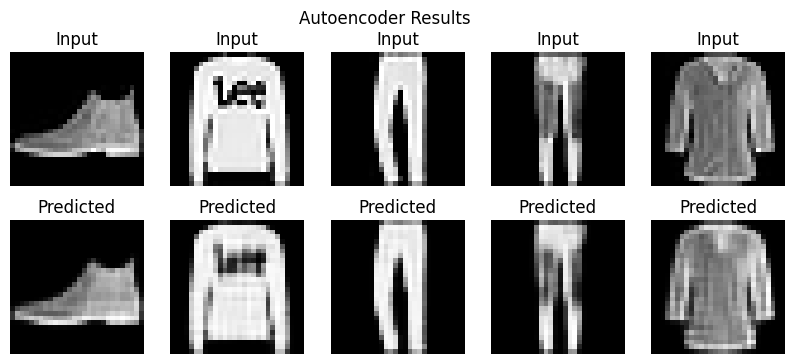

In [40]:
input = x_test[:5]
output = model.predict(input)
plt.figure(figsize=(10, 4))
for i in range(5):
    ax = plt.subplot(2, 5, i + 1)
    plt.imshow(input[i].reshape(28, 28), cmap='gray')
    ax.set_title("Input")
    ax.axis('off')

    ax = plt.subplot(2, 5, i + 6)
    plt.imshow(output[i].reshape(28, 28), cmap='gray')
    ax.set_title("Predicted")
    ax.axis('off')
plt.suptitle("Autoencoder Results")

Let's see if the model can handle removing noise from some images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


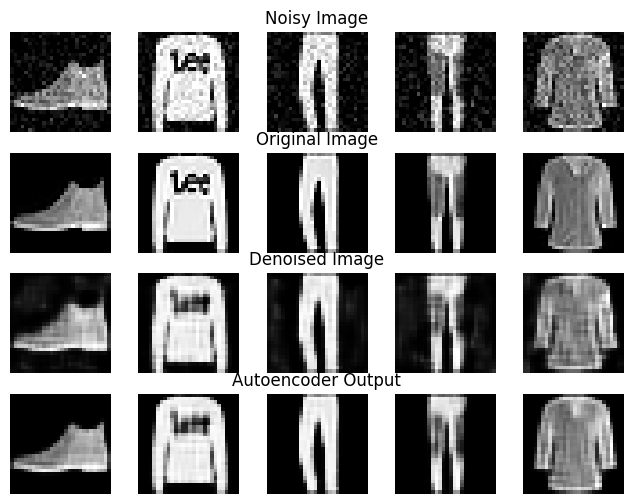

In [42]:
noise_factor = 0.1
noise = np.random.normal(loc=0.0, scale=1.0, size=input.shape)
noisy_images = input + noise_factor * noise
noisy_images = np.clip(noisy_images, 0., 1.)
noisy_output = model.predict(noisy_images)

fig, axes = plt.subplots(4, 5, figsize=(8, 6))
for i in range(5):
    ax = axes[0, i]
    ax.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
    if i == 2:
        ax.set_title("Noisy Image")
    ax.axis('off')

    ax = axes[1, i]
    ax.imshow(input[i].reshape(28, 28), cmap='gray')
    if i == 2:
        ax.set_title("Original Image")
    ax.axis('off')

    ax = axes[2, i]
    ax.imshow(noisy_output[i].reshape(28, 28), cmap='gray')
    if i == 2:
        ax.set_title("Denoised Image")
    ax.axis('off')
    
    ax = axes[3, i]
    ax.imshow(output[i].reshape(28, 28), cmap='gray')
    if i == 2:
        ax.set_title("Autoencoder Output")
    ax.axis('off')

Let's see if I can create a diffusion model from this.

In [ ]:
y_train = x_train
y_test = x_test

In [ ]:
def add_noise(x, noise_factor=0.1):
    noise = np.random.normal(loc=0.0, scale=1.0, size=x.shape)
    noisy_x = x + noise_factor * noise
    return np.clip(noisy_x, 0., 1.)

In [48]:
x_train_10p = add_noise(x_train, 0.1)
x_test_10p = add_noise(x_test, 0.1)
model.compile(optimizer='adam', loss='mse', metrics=['mse'])
history = model.fit(x_train_10p, y_train, epochs=3, batch_size=128,
                    validation_data=(x_test_10p, y_test))

Epoch 1/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - loss: 0.0062 - mse: 0.0062 - val_loss: 0.0045 - val_mse: 0.0045
Epoch 2/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 0.0044 - mse: 0.0044 - val_loss: 0.0044 - val_mse: 0.0044
Epoch 3/3
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - loss: 0.0044 - mse: 0.0044 - val_loss: 0.0043 - val_mse: 0.0043


In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.title("Train and Test losses")
plt.legend()
plt.show()

In [51]:
def test_image(image, noisy):
    fig, axes = plt.subplots(1, 3, figsize=(8, 4))
    ax = axes[0]
    ax.imshow(image.reshape(28, 28), cmap='gray')
    ax.set_title("Original Image")
    ax.axis('off')
    ax = axes[1]
    ax.imshow(noisy.reshape(28, 28), cmap='gray')
    ax.set_title("Noisy Image")
    ax.axis('off')
    ax = axes[2]
    ax.imshow(model.predict(noisy.reshape(1, 28, 28, 1)).reshape(28, 28), cmap='gray')
    ax.set_title("Denoised Image")
    ax.axis('off')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


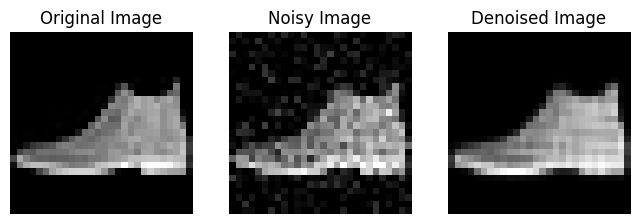

In [52]:
test_image(x_test[0:1], x_test_10p[0:1])

Let's continue training in increments of 10 percent more noise each run.

In [55]:
for noise_factor in np.linspace(0, 1, 1):
    x_train_noisy = add_noise(x_train, noise_factor)
    x_test_noisy = add_noise(x_test, noise_factor)
    model.compile(optimizer='adam', loss='mse', metrics=['mse'])
    history = model.fit(x_train_noisy, y_train, epochs=1, batch_size=1024,
                        validation_data=(x_test_noisy, y_test))
    test_image(x_test[0:1], x_test_noisy[0:1])

KeyboardInterrupt: 